### Preprocssing Training Set: Kalman Filtering and K-Means Discretize

In [1]:
from pathlib import Path
import pandas as pd
from src.gesture_from_path import gesture_from_path

import matplotlib.pyplot as plt
from src.kalman import kalman_filter

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


raw_dir = Path("data/raw_train")

col_names = ["ts", "Wx", "Wy", "Wz", "Ax", "Ay", "Az"]
sensor_cols = ["Wx", "Wy", "Wz", "Ax", "Ay", "Az"]

X_chunks = []
records = []

for txt_path in raw_dir.glob("*.txt"):
    # import raw training data
    raw_gesture = pd.read_csv(txt_path, header=None, sep=r"\s+", engine="python") # used regex to separate cols by any whitespace
    raw_gesture.columns = col_names

    # get gesture type
    gesture_type = gesture_from_path(txt_path)

    # apply 1D kalman filter to each column of IMU data
    ts = raw_gesture["ts"].to_numpy()
    fil_gesture = pd.DataFrame({"ts": ts})
    for col in sensor_cols:
        fil_gesture[col] = kalman_filter(raw_gesture[col].to_numpy(dtype="float64"))

    X = fil_gesture[sensor_cols].to_numpy(dtype=np.float32)
    X_chunks.append(X)

    # make record for final formatting later
    records.append(
        {
            "id": txt_path.stem,
            "gesture": gesture_type,
            "ts": ts,
            "X": X  
        }
    )

X_all = np.vstack(X_chunks) # merge all "per file" data points to one large numpy array

# scale all sensor data
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# fit K-means clustering to discretize observation space
num_clusters = 100
kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init="auto").fit(X_all_scaled)

# format all processed data ready for HMM
processed_dir = Path("data/processed_train")
processed_dir.mkdir(parents=True, exist_ok=True)

for record in records:
    # since we fit k-means onto scaled data, we must scale our data again
    X_scaled = scaler.transform(record["X"])
    O = kmeans.predict(X_scaled) # observations

    out_path = processed_dir / f"{record["id"]}.npz"
    np.savez(
        out_path,
        O = O,
        gesture = record["gesture"],
        ts = record["ts"],
        id = record["id"],
        num_clusters = num_clusters # store the number of clusters
    )

### Visualizing and Quantizing One Recording

In [2]:
import pandas as pd

# import raw training data
col_names = ["ts", "Wx", "Wy", "Wz", "Ax", "Ay", "Az"]
raw_gesture = pd.read_csv("./data/raw_train/beat3_03.txt", header=None, sep="\t ", engine="python")
raw_gesture.columns = col_names
raw_gesture.head()

,ts,Wx,Wy,Wz,Ax,Ay,Az
0,1,0.052353,-0.196747,0.238876,1.681351,6.739212,6.022507
1,5,0.044342,-0.206360,0.276794,1.509964,6.886795,6.034409
2,11,0.040070,-0.213303,0.297623,1.350479,6.970108,5.998703
3,15,0.039536,-0.210632,0.299759,1.324295,7.005814,6.017746
4,20,0.048615,-0.205826,0.284271,1.245743,7.003433,5.948715


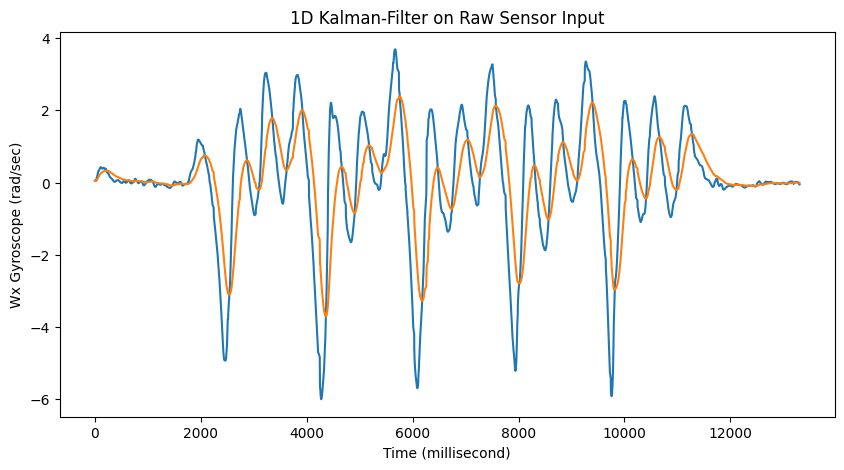

In [3]:
import matplotlib.pyplot as plt

from src.kalman import kalman_filter

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# apply 1D kalman filter to each column of IMU data
fil_gesture = pd.DataFrame(columns = raw_gesture.columns)
for col in fil_gesture.columns:
    if col == "ts":
        fil_gesture[col] = raw_gesture[col] # assume that ts is measured without error for consistency
    else:
        fil_gesture[col] = kalman_filter(raw_gesture[col])

# plot raw vs. smoothed
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(raw_gesture["ts"], raw_gesture["Wx"], label="Raw IMU Measurement")
ax.plot(fil_gesture["ts"], fil_gesture["Wx"], label="Kalman-Filtered IMU Measurement")
ax.set_xlabel("Time (millisecond)")
ax.set_ylabel("Wx Gyroscope (rad/sec)")
ax.set_title("1D Kalman-Filter on Raw Sensor Input")

plt.savefig("outputs/figures/kalman_filter", bbox_inches='tight')
plt.show()

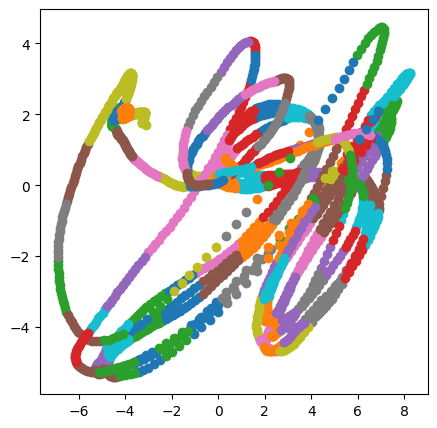

In [4]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

labels = KMeans(n_clusters=100, random_state=0, n_init='auto').fit_predict(fil_gesture.drop(labels="ts", axis=1, inplace=False))
X_decomp = PCA(n_components=2).fit_transform(fil_gesture.drop(labels="ts", axis=1, inplace=False))

fig, ax = plt.subplots(1,1,figsize=(5,5))

for i in np.unique(labels):
    plt.scatter(X_decomp[labels == i, 0], X_decomp[labels == i, 1], label = i)

plt.show()